QUESTION NUMBER 3 PAGE 553 OF THE TEXTBOOK "AN INTRODUCTION TO STATISTICAL LEARNING WITH APPLICATIONS IN PYTHON".

In this problem, you will perform K-means clustering manually, with
K = 2, on a small example with n = 6 observations and p = 2
features. The observations are as follows.
Obs. X1 X2
1 1 4
2 1 3
3 0 4
4 5 1
5 6 2
6 4 0

QUESTION A

Plot the observations.

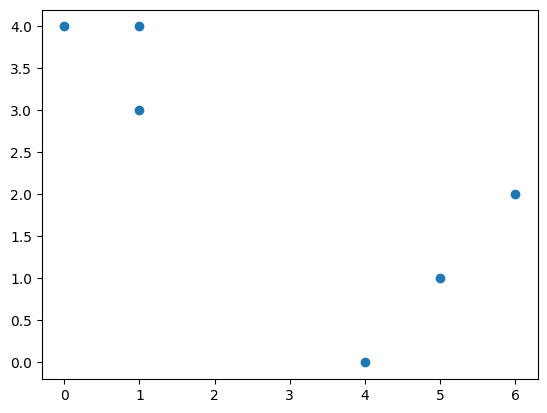

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.array([1, 1, 0, 5, 6, 4])
y = np.array([4, 3, 4, 1, 2, 0])
plt.scatter(X, y)
plt.show()

QUESTION B

Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster 
labels for each observation.

In [2]:
#Assigning each data point to a random cluster
np.random.seed(2)
labels = np.random.choice([1, 2], size=6)
print("Initial labels:", labels)
for i, label in enumerate(labels, start = 1):
    print(f'Data point {i} is assigned to cluster {label}')

Initial labels: [1 2 2 1 1 2]
Data point 1 is assigned to cluster 1
Data point 2 is assigned to cluster 2
Data point 3 is assigned to cluster 2
Data point 4 is assigned to cluster 1
Data point 5 is assigned to cluster 1
Data point 6 is assigned to cluster 2


QUESTION C

Compute the centroid for each cluster.

In [3]:
#Function to compute centroids
def compute_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(1, k+1)])

#Combining the X-array and y-array
data_points = np.column_stack((X, y))
data_points

array([[1, 4],
       [1, 3],
       [0, 4],
       [5, 1],
       [6, 2],
       [4, 0]])

In [4]:
centroids1 = compute_centroids(data_points, labels, 2)
centroids1

array([[4.        , 2.33333333],
       [1.66666667, 2.33333333]])

QUESTION D

Assign each observation to the centroid to which it is closest, in
terms of Euclidean distance. Report the cluster labels for each
observation.

In [5]:
#Calculating the distance of each data point to the centroid
from scipy.spatial.distance import cdist

dist1 = cdist(data_points, centroids1)
print(dist1)

[[3.43187671 1.79505494]
 [3.07318149 0.94280904]
 [4.33333333 2.3570226 ]
 [1.66666667 3.59010987]
 [2.02758751 4.34613494]
 [2.33333333 3.29983165]]


In [6]:
#Assigning to the appropriate cluster based on the distance to the closest distance to the centroids
cluster1 = np.argmin(dist1, axis = 1)
cluster1 = cluster1 + 1
print(cluster1)

[2 2 2 1 1 1]


QUESTION E

Repeat (c) and (d) until the answers obtained stop changing.

In [7]:
#Calculating the new centroids
centroids2 = compute_centroids(data_points, cluster1, 2)
print(centroids2)

[[5.         1.        ]
 [0.66666667 3.66666667]]


In [8]:
#Calculating the distance of each data point to the new centroids
dist2 = cdist(data_points, centroids1)
print(dist2)

[[3.43187671 1.79505494]
 [3.07318149 0.94280904]
 [4.33333333 2.3570226 ]
 [1.66666667 3.59010987]
 [2.02758751 4.34613494]
 [2.33333333 3.29983165]]


In [9]:
#Assigning to the appropriate cluster based on the distance to the closest distance to the centroids
cluster2 = np.argmin(dist2, axis = 1)
cluster2 = cluster2 + 1
print(cluster2)

[2 2 2 1 1 1]


It does not change anymore, so the final result is:
Data point 1 is assigned to cluster 2
Data point 2 is assigned to cluster 2
Data point 3 is assigned to cluster 2
Data point 4 is assigned to cluster 1
Data point 5 is assigned to cluster 1
Data point 6 is assigned to cluster 1

QUESTION F

In your plot from (a), color the observations according to thecluster labels obtained.

Text(0.5, 0, 'X1')

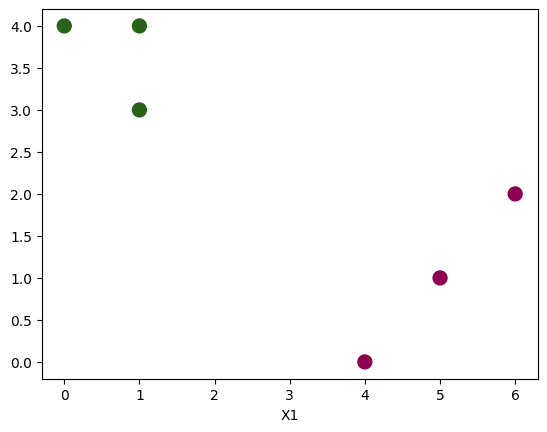

In [10]:
plt.scatter(data_points[:, 0], data_points[:, 1], c = cluster2, cmap = 'PiYG', s = 100)
plt.xlabel('X1')